# Dataset 4 — Bike Sharing Demand (Kaggle)

## Descripción general
Este dataset contiene el registro histórico de un programa de alquiler de bicicletas compartidas en Washington D.C. Combina datos de la duración del alquiler con información climática y estacional. A diferencia de otros datasets, este tiene una fuerte componente temporal, donde la demanda fluctúa drásticamente según la hora del día y el día de la semana.

## Objetivo
**Problema de Regresión Múltiple** — El objetivo es predecir la demanda total de bicicletas (columna `count`) para una hora determinada, basándose en variables ambientales (temperatura, clima, humedad) y temporales.

## Estructura original
- **Archivo:** `train.csv` (10,886 filas, 12 columnas).
- **Variable objetivo:** `count` (Número total de alquileres).
- **Relación matemática:** `count` = `casual` + `registered`.

## Tipos de columnas
| Tipo | Ejemplos |
|------|---------|
| Temporal (cruda) | `datetime` (ej. 2011-01-01 00:00:00) |
| Categórica (clima) | `season` (1:primavera, 2:verano...), `weather` (1:despejado, 2:niebla...) |
| Numérica continua | `temp`, `atemp` (sensación térmica), `humidity`, `windspeed` |
| Binaria | `holiday` (festivo), `workingday` (día laboral) |

## Tratamiento aplicado

### 1. Ingeniería de Características (Feature Engineering)
Los modelos de Machine Learning no pueden interpretar una fecha en formato de texto. Se realizó una transformación de la columna `datetime` para extraer tres nuevas variables numéricas:
- **`hour`**: Fundamental para capturar las horas pico (entrada y salida laboral).
- **`month`**: Para capturar tendencias estacionales mensuales.
- **`dayofweek`**: Para diferenciar el comportamiento de alquiler en fines de semana vs. días de semana.
Posteriormente, se eliminó la columna `datetime` original.

### 2. Eliminación de Fuga de Datos (Data Leakage)
Se identificó que las columnas `casual` (usuarios no registrados) y `registered` (usuarios registrados) suman exactamente el valor de `count`. 
- **Decisión:** Se eliminaron ambas columnas. Incluirlas en el entrenamiento sería "hacer trampa", ya que el modelo conocería parte de la respuesta antes de predecir, resultando en un modelo inútil para datos futuros donde solo conocemos el clima y la hora.

### 3. Codificación de Variables Categóricas
Las variables `season` y `weather`, aunque vienen como números (1-4), representan categorías sin un orden lineal real. Se convirtieron a tipo cadena (string) y se les aplicó **One-Hot Encoding** (`pd.get_dummies`), transformándolas en columnas independientes de 0 y 1.

### 4. Justificación de OMITIR el Balanceo
Este es un problema de **Regresión**, donde se busca predecir un valor numérico continuo (`count`). Las técnicas de balanceo (como Undersampling) solo se aplican en problemas de Clasificación para equilibrar etiquetas de categorías. En este caso, se requiere mantener la distribución natural de la demanda.

### 5. División de Datos (80/20)
Debido a que los datos originales están ordenados cronológicamente, se aplicó una permutación aleatoria (`np.random.permutation`) antes de la división. Esto garantiza que el conjunto de entrenamiento (80%) y el de prueba (20%) tengan una representación equitativa de todos los años, estaciones y horas del día.

### 6. Normalización Matemática (Z-Score)
Para evitar que variables con rangos grandes (como `humidity` que llega a 100) dominen sobre variables pequeñas (como `temp`), se aplicó estandarización:
- Se calculó la media ($\mu$) y desviación estándar ($\sigma$) del conjunto de entrenamiento.
- Se transformaron ambos conjuntos ($X_{train}$ y $X_{test}$) usando esos parámetros.
- Se añadió la **columna de unos** al inicio de las matrices para representar el término de sesgo (bias/intercepto) necesario para el algoritmo de aprendizaje.

## Resultado final
| | Antes | Después |
|--|-------|---------|
| Filas | 10,886 | 10,886 (Divididas 80/20) |
| Columnas | 12 | 19 (incluyendo columna de sesgo) |
| Valores faltantes | 0 | 0 |
| Tipo de problema | - | Regresión Lineal/Múltiple |

## ¿Está balanceado?
**No, y no es necesario.** A diferencia del dataset de MIMIC-III (que era de clasificación binaria), el dataset de **Bike Sharing** es un problema de **Regresión**. 

En la regresión, la variable objetivo (`count`) es un número continuo, no una categoría. Por lo tanto, no existen "clases" que igualar. Lo que se observa en este caso es la **distribución** de la variable:
- Existe un sesgo hacia la derecha (muchas horas con pocos alquileres y pocas horas con una demanda masiva).
- El modelo debe aprender a predecir todo el espectro de valores basándose en las variables climáticas y temporales, por lo que aplicar técnicas de balanceo (como Undersampling) sería contraproducente, ya que eliminaría información valiosa sobre la variabilidad real de la demanda.

Shape original: (10886, 12)
Variable objetivo - count (Total de bicicletas):
  Min: 1
  Max: 977
  Media: 191.57

Shape después de extraer fechas y eliminar Data Leakage: (10886, 12)

Columnas eliminadas por tener >50% de NaN:
  Ninguna columna superó el 50% de nulos.

NaN restantes: 0
Shape después de one-hot encoding: (10886, 18)

 OMITIDO: BALANCEO DE CLASES 
Este es un problema de REGRESIÓN (predecir cantidad numérica 'count').
El balanceo solo aplica para clasificación. 

 DESCRIPCIÓN DEL DATASET PREPARADO 
Nombre: Bike Sharing Demand (Kaggle)
Problema: Regresión — predecir la demanda total de bicicletas ('count')
Filas listas: 10886
Columnas predictoras: 17
Variable objetivo: count
NaN restantes: 0

Dataset guardado como 'BikeSharing_preparado.csv' 

 INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN 
Variables en memoria listas para el modelo matemático
Tamaño X_train_norm: (8708, 18)
Tamaño y_train:      (8708,)
Tamaño X_test_norm:  (2178, 18)
Tamaño y_test:       (2178,)


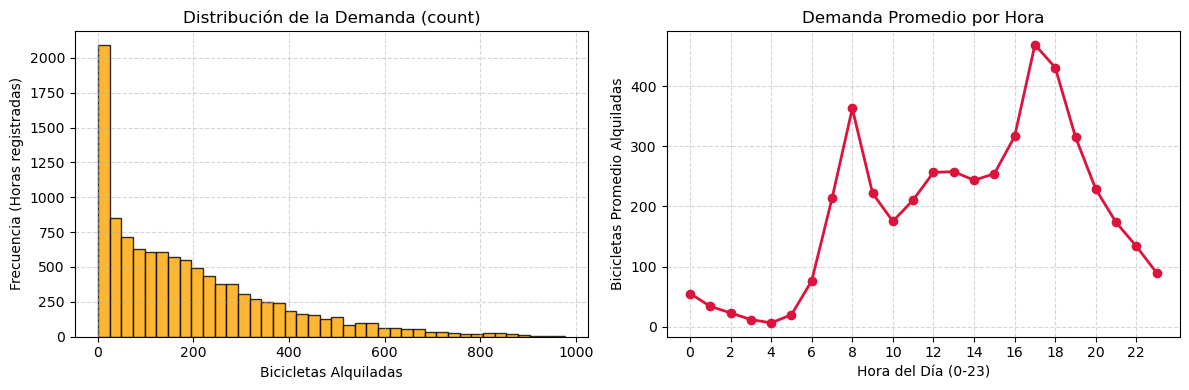

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 4: Bike Sharing (Regresión)

# 1. CARGAR
ruta_bike = r'C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset4\train.csv' 
df = pd.read_csv(ruta_bike)

print("Shape original:", df.shape)
print("Variable objetivo - count (Total de bicicletas):")
print(f"  Min: {df['count'].min()}")
print(f"  Max: {df['count'].max()}")
print(f"  Media: {df['count'].mean():.2f}")

# --- TRUCO PRO: INGENIERÍA DE CARACTERÍSTICAS (FECHAS) ---
# Convertimos el texto a formato fecha para extraer datos matemáticos útiles
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.dayofweek

# 2. ELIMINAR COLUMNAS INÚTILES Y PELIGROSAS (DATA LEAKAGE)
# - datetime: Ya extrajimos la hora y el mes, el texto original ya no sirve.
# - casual y registered: Sumadas dan 'count'. Dejarlas sería hacer trampa.
df = df.drop(columns=['datetime', 'casual', 'registered'])
print("\nShape después de extraer fechas y eliminar Data Leakage:", df.shape)

# Convertimos season y weather a texto temporalmente para que el One-Hot Encoding 
# las reconozca como categorías reales, ya que un clima 4 no vale "el doble" que un clima 2.
df['season'] = df['season'].astype(str)
df['weather'] = df['weather'].astype(str)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
print("\nColumnas eliminadas por tener >50% de NaN:")
if cols_muchos_nulos:
    for col in cols_muchos_nulos:
        pct = df[col].isnull().sum() / len(df) * 100
        print(f"  {col}: {pct:.1f}% nulos")
else:
    print("  Ninguna columna superó el 50% de nulos.")
df = df.drop(columns=cols_muchos_nulos)

# 4. IMPUTAR NaN RESTANTES
cols_numericas = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
for col in cols_numericas:
    if col == 'count':
        continue
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f"  {col}: NaN imputados con mediana ({mediana})")

cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Desconocido')

print("\nNaN restantes:", df.isnull().sum().sum())

# 5. ONE-HOT ENCODING
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns.tolist())
print("Shape después de one-hot encoding:", df.shape)

# 6. BALANCEAR CLASES
print("\n OMITIDO: BALANCEO DE CLASES ")
print("Este es un problema de REGRESIÓN (predecir cantidad numérica 'count').")
print("El balanceo solo aplica para clasificación. \n")

# 7. MOVER TARGET (count) AL FINAL
cols = [c for c in df.columns if c != 'count'] + ['count']
df = df[cols]

# 8. RESUMEN FINAL
print(" DESCRIPCIÓN DEL DATASET PREPARADO ")
print(f"Nombre: Bike Sharing Demand (Kaggle)")
print(f"Problema: Regresión — predecir la demanda total de bicicletas ('count')")
print(f"Filas listas: {df.shape[0]}")
print(f"Columnas predictoras: {df.shape[1] - 1}")
print(f"Variable objetivo: count")
print(f"NaN restantes: {df.isnull().sum().sum()}")

# 9. GUARDAR
df.to_csv('BikeSharing_preparado.csv', index=False)
print("\nDataset guardado como 'BikeSharing_preparado.csv' ")

# DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA
print("\n INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN ")

# SOLUCIÓN: Agregamos .astype(float) para convertir los True/False en 1.0 y 0.0
X = df.drop('count', axis=1).astype(float).values
y = df['count'].astype(float).values

# Calcular el índice de corte para el 80%
m = len(y)
limite = int(m * 0.8)

# Desordenar los datos (crucial para mezclar días de lluvia, sol, invierno, etc.)
np.random.seed(42)
indices = np.random.permutation(m)
X = X[indices]
y = y[indices]

# División 80/20
X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

# Función manual para Normalizar (Estandarización)
def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    sigma[sigma == 0] = 1 # Evitar divisiones por cero
    X_norm = (X_data - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos usando SOLO los datos de entrenamiento
X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

# Agregar la columna de unos (Término de sesgo/Intercepto) a ambos conjuntos
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("Variables en memoria listas para el modelo matemático")
print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño y_train:      {y_train.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")
print(f"Tamaño y_test:       {y_test.shape}")

# 10. GRÁFICAS PARA REGRESIÓN
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['count'], bins=40, color='orange', edgecolor='black', alpha=0.8)
plt.title("Distribución de la Demanda (count)")
plt.xlabel("Bicicletas Alquiladas")
plt.ylabel("Frecuencia (Horas registradas)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
# Gráfica de demanda promedio por hora del día
demanda_por_hora = df.groupby('hour')['count'].mean()
plt.plot(demanda_por_hora.index, demanda_por_hora.values, marker='o', color='crimson', linewidth=2)
plt.title("Demanda Promedio por Hora")
plt.xlabel("Hora del Día (0-23)")
plt.ylabel("Bicicletas Promedio Alquiladas")
plt.xticks(range(0, 24, 2))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
%matplotlib inline
df=pd.read_csv(r'BikeSharing_preparado.csv')

In [76]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X,  axis=0)
    sigma[sigma == 0] = 1e-15
    return (X - mu) / sigma, mu, sigma

def computeCost(X, y, theta):
    m = y.size
    h = np.dot(X, theta)
    return (1 / (2*m)) * np.sum(np.square(h - y))

def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.size
    J_history = []
    theta = theta.copy()
    for _ in range(num_iters):
        h = np.dot(X, theta)
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))
        J_history.append(computeCost(X, y, theta))
    return theta, J_history

def normalEqn(X, y):
    return np.dot(np.linalg.pinv(np.dot(X.T, X)).dot(X.T), y)


X_original = df.drop(columns=['count']).astype(float).values
y          = df['count'].values
m          = y.size
print(f"Ejemplos (m): {m} | Características (n): {X_original.shape[1]}")

Ejemplos (m): 10886 | Características (n): 17


In [77]:
import numpy
np.random.seed(42)
idx   = np.random.permutation(m)
lim   = int(0.75 * m)
X_tr, y_tr = X_original[idx[:lim]],  y[idx[:lim]]
X_te, y_te = X_original[idx[lim:]], y[idx[lim:]]

X_tr_norm, mu, sigma = featureNormalize(X_tr)
X_te_norm = (X_te - mu) / (sigma + 1e-15)

X_tr_ready = np.concatenate([np.ones((X_tr_norm.shape[0], 1)), X_tr_norm], axis=1)
X_te_ready = np.concatenate([np.ones((X_te_norm.shape[0], 1)), X_te_norm], axis=1)
print(f"Train: {X_tr_ready.shape} | Test: {X_te_ready.shape}")

Train: (8164, 18) | Test: (2722, 18)


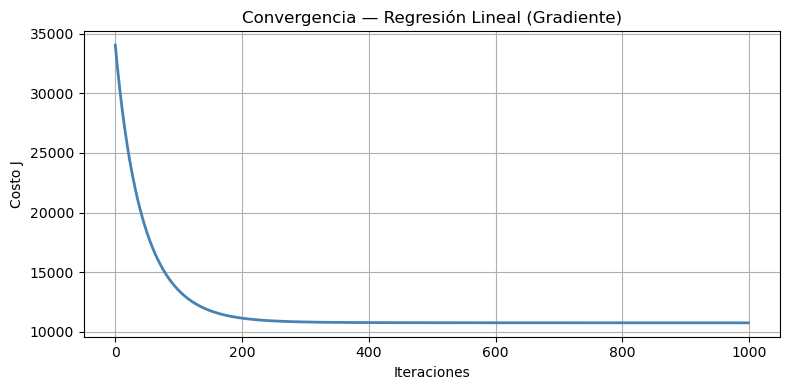

Costo final (train): 10758.9020


In [86]:
alpha    = 0.01
num_iters= 1000
theta0   = np.zeros(X_tr_ready.shape[1])

theta_gd, J_hist = gradientDescent(X_tr_ready, y_tr, theta0, alpha, num_iters)

plt.figure(figsize=(8,4))
plt.plot(J_hist, color='steelblue', lw=2)
plt.title("Convergencia — Regresión Lineal (Gradiente)")
plt.xlabel("Iteraciones"); plt.ylabel("Costo J"); plt.grid(True)
plt.tight_layout(); plt.show()
print(f"Costo final (train): {J_hist[-1]:.4f}")

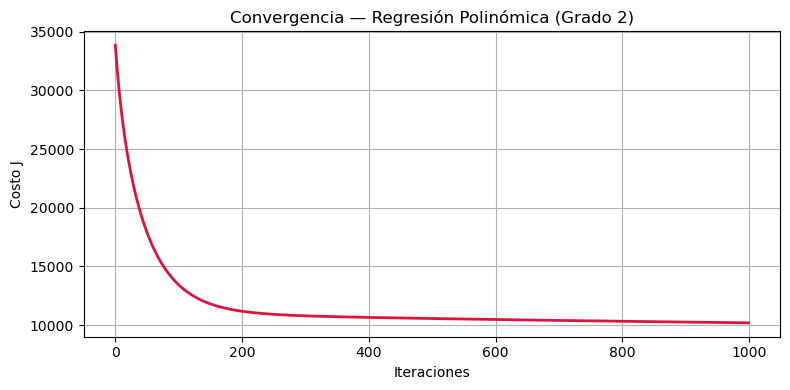

Costo final polinómico (train): 10197.6189


In [87]:
X_poly = np.concatenate([X_tr, np.power(X_tr, 2)], axis=1)
X_poly_norm, mu_p, sigma_p = featureNormalize(X_poly)
X_poly_ready = np.concatenate([np.ones((X_poly_norm.shape[0],1)), X_poly_norm], axis=1)

theta_poly, J_hist_poly = gradientDescent(X_poly_ready, y_tr,
                                           np.zeros(X_poly_ready.shape[1]),
                                           0.01, 1000)[:2]

plt.figure(figsize=(8,4))
plt.plot(J_hist_poly, color='crimson', lw=2)
plt.title("Convergencia — Regresión Polinómica (Grado 2)")
plt.xlabel("Iteraciones"); plt.ylabel("Costo J"); plt.grid(True)
plt.tight_layout(); plt.show()
print(f"Costo final polinómico (train): {J_hist_poly[-1]:.4f}")

In [88]:
X_full_ready = np.concatenate([np.ones((m, 1)), X_original], axis=1)
theta_normal  = normalEqn(X_full_ready, y)
costo_normal  = computeCost(X_full_ready, y, theta_normal)
print(f"Costo exacto (Ecuación Normal): {costo_normal:.4f}")

Costo exacto (Ecuación Normal): 10691.2846


In [89]:
def mae(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

def r2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - np.mean(y_real))**2)
    return 1 -ss_res / ss_tot

pred_gd  = X_te_ready.dot(theta_gd)

X_te_poly = np.concatenate([X_te, np.power(X_te, 2)], axis=1)
X_te_poly_norm = (X_te_poly - mu_p) / (sigma_p + 1e-15)
X_te_poly_ready = np.concatenate([np.ones((X_te_poly_norm.shape[0],1)), X_te_poly_norm], axis=1)
pred_poly = X_te_poly_ready.dot(theta_poly)

X_te_ne = np.concatenate([np.ones((X_te.shape[0],1)), X_te], axis=1)
pred_ne  = X_te_ne.dot(theta_normal)

print(f"{'Modelo':<25} {'MAE':>7} {'R²':>6}")
print(f"{'Lineal (Gradiente)':<25} {mae(y_te,pred_gd):>8.4f} {r2(y_te,pred_gd):>8.4f}")
print(f"{'Polinómica grado 2':<25} {mae(y_te,pred_poly):>8.4f} {r2(y_te,pred_poly):>8.4f}")
print(f"{'Ecuación Normal':<25} {mae(y_te,pred_ne):>8.4f} {r2(y_te,pred_ne):>8.4f}")


Modelo                        MAE     R²
Lineal (Gradiente)        106.5567   0.3614
Polinómica grado 2        103.0601   0.3947
Ecuación Normal           106.5193   0.3622
